# Notebook of the analyses of bank campaigns
The data showed in the ppt were generated here below. We selected the following banks for our project: ING, N26 (challenger bank) and BNP Paribas Fortis (traditional bank). 
First part of the analyses focuses on all campaigns taken together. The second part of the analyses focused on a permanent offer of banks (debit card) and on a time-limited offer (youth account). 

#### 1. Import libraries of interest

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#### 2. Load dataset of interest

In [29]:
# df of interest 
df = pd.read_csv("data/demo_campaigns_final.csv")

## I. Tone of the campaigns

Here, we consider all campaigns together. 

In [7]:
# group tones of interest 
emotional_appeal = ["humanity_score", "warmth_score", "emotionality_score"]
formality = ["formality_score"]
positive_energy = ["optimism_score", "energy_score"]
customer_oriented = ["accessibility_score", "customer_orientation_score"]
directness = ["directness_score"]
persuasion = ["persuasive_intensity_score", "cta_intensity_score"]
playfulness = ["playfulness_score"]

In [8]:
new_df = df[['bank']].copy()

In [9]:
new_df['emotional_appeal'] = df[emotional_appeal].mean(axis=1)
new_df['formality'] = df[formality].mean(axis=1)
new_df['positive_energy'] = df[positive_energy].mean(axis=1)
new_df['customer_oriented'] = df[customer_oriented].mean(axis=1)
new_df['directness'] = df[directness].mean(axis=1)
new_df['persuasion'] = df[persuasion].mean(axis=1)
new_df['playfulness'] = df[playfulness].mean(axis=1)

In [12]:
mean_df = new_df.groupby('bank', as_index=False).mean(numeric_only=True)
print(mean_df)

                 bank  emotional_appeal  formality  positive_energy  \
0  BNP Paribas Fortis          2.984848   3.545455         2.931818   
1                 ING          3.030303   2.909091         2.772727   
2                 N26          3.166667   2.500000         3.250000   

   customer_oriented  directness  persuasion  playfulness  
0           3.840909    4.000000    3.522727          1.5  
1           4.340909    4.272727    3.181818          1.5  
2           4.000000    4.000000    4.250000          2.5  


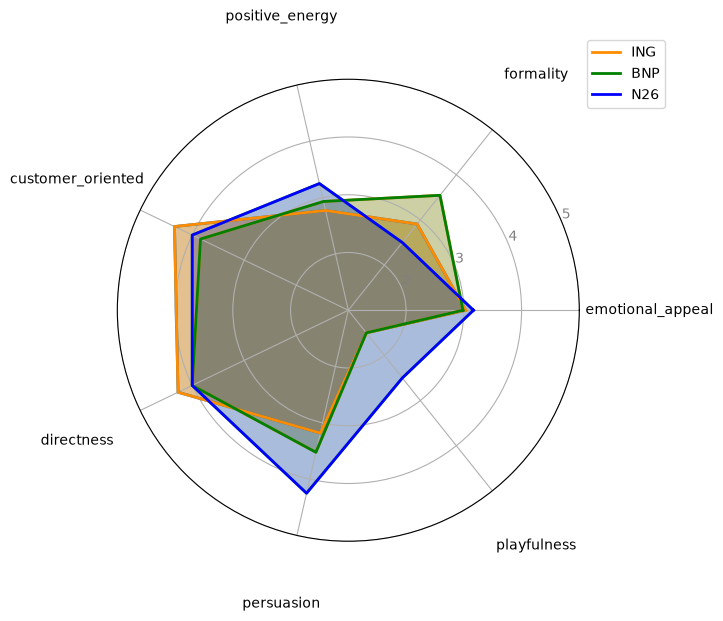

In [ ]:
## Create spider plot
# Categories
categories = new_df.columns[1:].tolist()

values_ing = mean_df[mean_df['bank'] == 'ING'].iloc[0, 1:].tolist()
values_bnp = mean_df[mean_df['bank'] == 'BNP Paribas Fortis'].iloc[0, 1:].tolist()
values_n26  = mean_df[mean_df['bank'] == 'N26'].iloc[0, 1:].tolist()


# Number of categories
N = len(categories)

# Angles
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Close the radar plot
angles += angles[:1]
values_ing += values_ing[:1]
values_bnp += values_bnp[:1]
values_n26 += values_n26[:1]

# Create plot
fig, ax = plt.subplots(
    figsize=(6, 6),
    subplot_kw=dict(polar=True)
)

# ING
ax.plot(angles, values_ing, linewidth=2, label="ING")
ax.fill(angles, values_ing, alpha=0.2)

# BNP
ax.plot(angles, values_bnp, linewidth=2, label="BNP")
ax.fill(angles, values_bnp, alpha=0.2)

# N26
ax.plot(angles, values_n26, linewidth=2, label="N26")
ax.fill(angles, values_n26, alpha=0.2)

# Category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

# Scale
ax.set_ylim(1, 5)
ax.set_yticks(range(1, 6))
ax.tick_params(axis='y', colors='grey')

ax.tick_params(axis='x', pad=40)

from matplotlib.lines import Line2D

# Plot the players
ax.plot(angles, values_ing, linewidth=2, color="darkorange")
ax.fill(angles, values_ing, color="darkorange", alpha=0.4)

ax.plot(angles, values_bnp, linewidth=2, color="green")
ax.fill(angles, values_bnp, color="green", alpha=0.2)

ax.plot(angles, values_n26, linewidth=2, color="blue")
ax.fill(angles, values_n26, color="blue", alpha=0.2)

# Custom legend
legend_elements = [
    Line2D([0], [0], color="darkorange", linewidth=2, label="ING"),
    Line2D([0], [0], color="green", linewidth=2, label="BNP"),
    Line2D([0], [0], color="blue", linewidth=2, label="N26")
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.2, 1.1)
)

# plt.savefig("figs/my_tone_all_banks.jpeg", format="jpeg", dpi=300, bbox_inches="tight")
plt.show()

### 3. What about the tone in the product: current accounts > debit cards ?
Here, only the debit card campaigns of the banks of interest are considered. They are designated by the URLs in the following code chunk.

In [18]:
my_urls = [
    "https://www.bnpparibasfortis.be/en/public/individuals/daily-banking/accounts/current-account-compare",
    "https://www.ing.be/en/individuals/current-accounts-packs",
    "https://n26.com/en-be/plans"

]


url_df = df[df['url'].isin(my_urls)]
new_url_df = url_df[['bank']].copy()



new_url_df['emotional_appeal'] = url_df[emotional_appeal].mean(axis=1)
new_url_df['formality'] = url_df[formality].mean(axis=1)
new_url_df['positive_energy'] = url_df[positive_energy].mean(axis=1)
new_url_df['customer_oriented'] = url_df[customer_oriented].mean(axis=1)
new_url_df['directness'] = url_df[directness].mean(axis=1)
new_url_df['persuasion'] = url_df[persuasion].mean(axis=1)
new_url_df['playfulness'] = url_df[playfulness].mean(axis=1)

In [15]:
print(new_url_df)

                  bank  emotional_appeal  formality  positive_energy  \
1   BNP Paribas Fortis          2.666667        4.0              2.5   
25                 ING          3.000000        3.0              3.0   
45                 N26          2.666667        3.0              2.5   

    customer_oriented  directness  persuasion  playfulness  
1                 3.5         4.0         3.5          1.0  
25                4.5         4.0         4.0          2.0  
45                4.0         4.0         4.0          2.0  


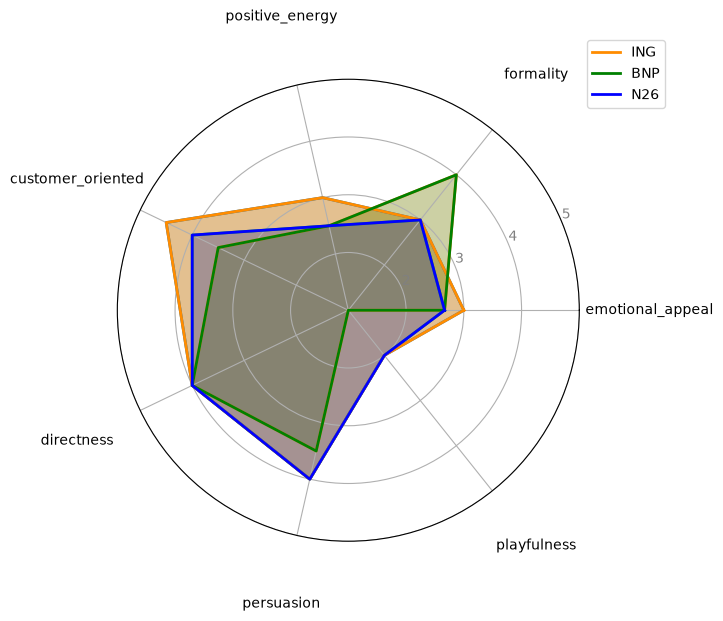

In [ ]:
# Categories
categories = new_url_df.columns[1:].tolist()

values_ing = new_url_df[new_url_df['bank'] == 'ING'].iloc[0, 1:].tolist()
values_bnp = new_url_df[new_url_df['bank'] == 'BNP Paribas Fortis'].iloc[0, 1:].tolist()
values_n26  = new_url_df[new_url_df['bank'] == 'N26'].iloc[0, 1:].tolist()


# Number of categories
N = len(categories)

# Angles
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Close the radar plot
angles += angles[:1]
values_ing += values_ing[:1]
values_bnp += values_bnp[:1]
values_n26 += values_n26[:1]

# Create plot
fig, ax = plt.subplots(
    figsize=(6, 6),
    subplot_kw=dict(polar=True)
)

# ING
ax.plot(angles, values_ing, linewidth=2, label="ING")
ax.fill(angles, values_ing, alpha=0.2)

# BNP
ax.plot(angles, values_bnp, linewidth=2, label="BNP")
ax.fill(angles, values_bnp, alpha=0.2)

# N26
ax.plot(angles, values_n26, linewidth=2, label="N26")
ax.fill(angles, values_n26, alpha=0.2)

# Category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

# Scale
ax.set_ylim(1, 5)
ax.set_yticks(range(1, 6))
ax.tick_params(axis='y', colors='grey')

ax.tick_params(axis='x', pad=40)

from matplotlib.lines import Line2D

# Plot the players
ax.plot(angles, values_ing, linewidth=2, color="darkorange")
ax.fill(angles, values_ing, color="darkorange", alpha=0.4)

ax.plot(angles, values_bnp, linewidth=2, color="green")
ax.fill(angles, values_bnp, color="green", alpha=0.2)

ax.plot(angles, values_n26, linewidth=2, color="blue")
ax.fill(angles, values_n26, color="blue", alpha=0.2)

# Custom legend
legend_elements = [
    Line2D([0], [0], color="darkorange", linewidth=2, label="ING"),
    Line2D([0], [0], color="green", linewidth=2, label="BNP"),
    Line2D([0], [0], color="blue", linewidth=2, label="N26")
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.2, 1.1)
)

# plt.savefig("figs/tone_all_debits.jpeg", format="jpeg", dpi=300, bbox_inches="tight")
plt.show()

### 4. Tone in a time-limited offer: children account
Only the two URLs below were considered (ING and BNP). N26 ad does not go through their website. 

In [20]:
my_urls = [
    "https://www.ing.be/en/individuals/campaign/current-account-free-youth",
    "https://www.bnpparibasfortis.be/en/public/individuals/daily-banking/accounts/current-account/youth-account"

]

rl_df = df[df['url'].isin(my_urls)]
new_url_df = url_df[['bank']].copy()



new_url_df['emotional_appeal'] = url_df[emotional_appeal].mean(axis=1)
new_url_df['formality'] = url_df[formality].mean(axis=1)
new_url_df['positive_energy'] = url_df[positive_energy].mean(axis=1)
new_url_df['customer_oriented'] = url_df[customer_oriented].mean(axis=1)
new_url_df['directness'] = url_df[directness].mean(axis=1)
new_url_df['persuasion'] = url_df[persuasion].mean(axis=1)
new_url_df['playfulness'] = url_df[playfulness].mean(axis=1)

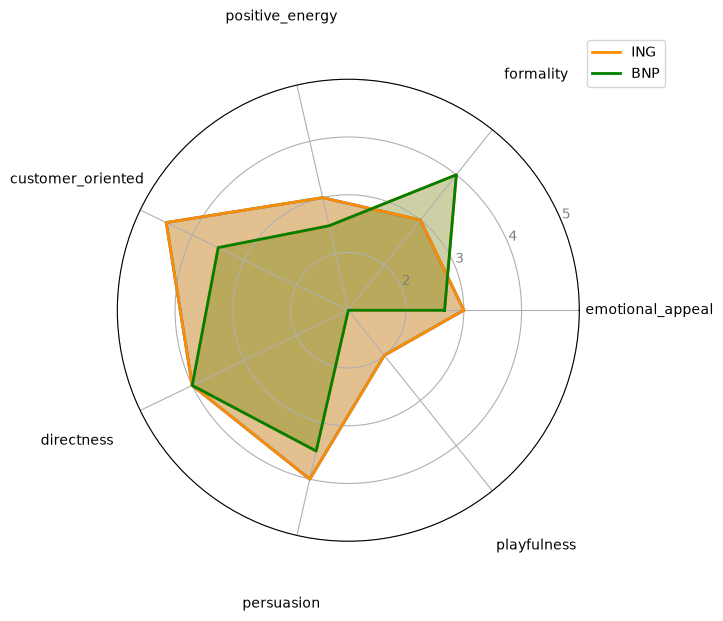

In [ ]:
# Categories
categories = new_url_df.columns[1:].tolist()

values_ing = new_url_df[new_url_df['bank'] == 'ING'].iloc[0, 1:].tolist()
values_bnp = new_url_df[new_url_df['bank'] == 'BNP Paribas Fortis'].iloc[0, 1:].tolist()
#values_n26  = new_url_df[new_url_df['bank'] == 'N26'].iloc[0, 1:].tolist()


# Number of categories
N = len(categories)

# Angles
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Close the radar plot
angles += angles[:1]
values_ing += values_ing[:1]
values_bnp += values_bnp[:1]
#values_n26 += values_n26[:1]

# Create plot
fig, ax = plt.subplots(
    figsize=(6, 6),
    subplot_kw=dict(polar=True)
)

# ING
ax.plot(angles, values_ing, linewidth=2, label="ING")
ax.fill(angles, values_ing, alpha=0.2)

# BNP
ax.plot(angles, values_bnp, linewidth=2, label="BNP")
ax.fill(angles, values_bnp, alpha=0.2)

# N26
# ax.plot(angles, values_n26, linewidth=2, label="N26")
# ax.fill(angles, values_n26, alpha=0.2)

# Category labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

# Scale
ax.set_ylim(1, 5)
ax.set_yticks(range(1, 6))
ax.tick_params(axis='y', colors='grey')

ax.tick_params(axis='x', pad=40)

from matplotlib.lines import Line2D

# Plot the players
ax.plot(angles, values_ing, linewidth=2, color="darkorange")
ax.fill(angles, values_ing, color="darkorange", alpha=0.4)

ax.plot(angles, values_bnp, linewidth=2, color="green")
ax.fill(angles, values_bnp, color="green", alpha=0.2)

# ax.plot(angles, values_n26, linewidth=2, color="blue")
# ax.fill(angles, values_n26, color="blue", alpha=0.2)

# Custom legend
legend_elements = [
    Line2D([0], [0], color="darkorange", linewidth=2, label="ING"),
    Line2D([0], [0], color="green", linewidth=2, label="BNP")#,
    #Line2D([0], [0], color="blue", linewidth=2, label="N26")
]

ax.legend(
    handles=legend_elements,
    loc="upper right",
    bbox_to_anchor=(1.2, 1.1)
)

# plt.savefig("figs/tone_children.jpeg", format="jpeg", dpi=300, bbox_inches="tight")
plt.show()

### II. Images of the campaigns
Let's compare now visual features of the three banks of interest and of their individual offers.
Based on all the features we extracted, we select the following that were manually validated: 
- subject of image (people, icons, none, products)
- visual layout (grid, hero, cards, editorial, minimal)
- paragraph density (high, medium, low)

In [ ]:
my_urls = [
    "https://www.ing.be/en/individuals/campaign/current-account-free-youth",
    "https://www.bnpparibasfortis.be/en/public/individuals/daily-banking/accounts/current-account/youth-account"

]

columns_interest = ["bank", "url", "visual_imagery_subjects", "visual_layout", "visual_visible_paragraph_density"]

visual_df = df[columns_interest]
visual_2 = visual_df[visual_df['url'].isin(my_urls)]

In [ ]:
counts = (
    visual_2.groupby('bank')['visual_imagery_subjects'] # change df here
      .value_counts()
      .unstack(fill_value=0)
)

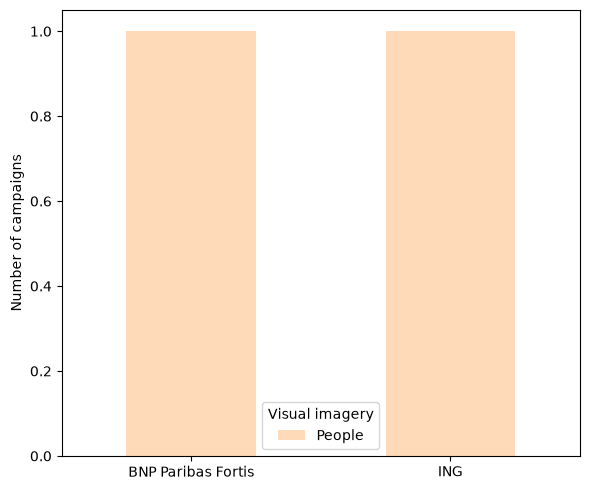

In [ ]:
colors = ["peachpuff", "sandybrown", "chocolate", "saddlebrown"]

counts.plot(
    kind='bar',
    stacked=True,
    figsize=(6, 5),
    color = colors
)

plt.xlabel('')
plt.ylabel('Number of campaigns')
plt.title('')
plt.xticks(rotation=0)
plt.legend(title='Visual imagery')
plt.tight_layout()
# plt.savefig("figs/visual_children.jpeg", format="jpeg", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# how many images do we see? 
my_urls_2 = [
    "https://www.ing.be/en/individuals/campaign/current-account-free-youth",
    "https://www.bnpparibasfortis.be/en/public/individuals/daily-banking/accounts/current-account/youth-account"

]

my_urls = [
    "https://www.bnpparibasfortis.be/en/public/individuals/daily-banking/accounts/current-account-compare",
    "https://www.ing.be/en/individuals/current-accounts-packs",
    "https://n26.com/en-be/plans"

]


columns_interest = ["metrics_visible_image_count", "bank", "url"]

image_df = df[columns_interest]

image_2 = image_df['url'].isin(my_urls_2)
image_3 = image_df['url'].isin(my_urls)

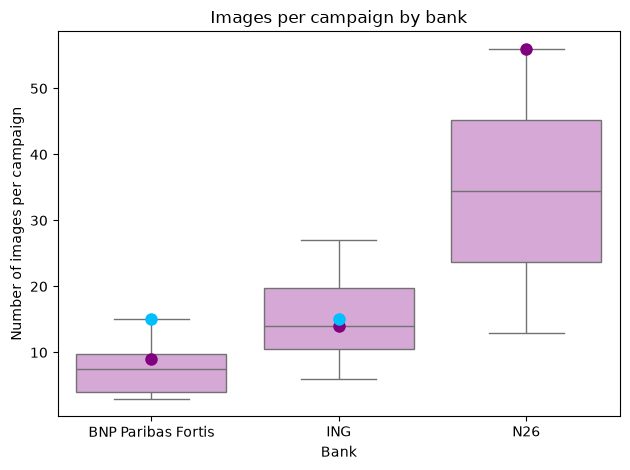

<Figure size 640x480 with 0 Axes>

In [ ]:
columns_interest = ["metrics_visible_image_count", "bank", "url"]

image_df = df[columns_interest]

image_3 = image_df['url'].isin(my_urls)
sns.boxplot(
    data=image_df,
    color = "plum",
    x='bank',
    y='metrics_visible_image_count'#,
   # jitter=True
)

# Highlight selected URLs
sns.stripplot(
    data=image_df[image_3],
    x='bank',
    y='metrics_visible_image_count',
    color='purple',
    size=9,
    jitter=True
)

sns.stripplot(
    data=image_df[image_2],
    x='bank',
    y='metrics_visible_image_count',
    color='deepskyblue',
    size=9,
    jitter=True
)

plt.xlabel('Bank')
plt.ylabel('Number of images per campaign')
plt.title('Images per campaign by bank')
plt.tight_layout()
plt.show()

# plt.savefig("figs/visual_count_all3.jpeg", format="jpeg", dpi=300, bbox_inches="tight")
plt.show()

### III. Text of campaigns
Let's compare now the following text features for the three banks, and the two examples of campaign: 
- paragraph count
- metrics word count
- quantitative sentence count

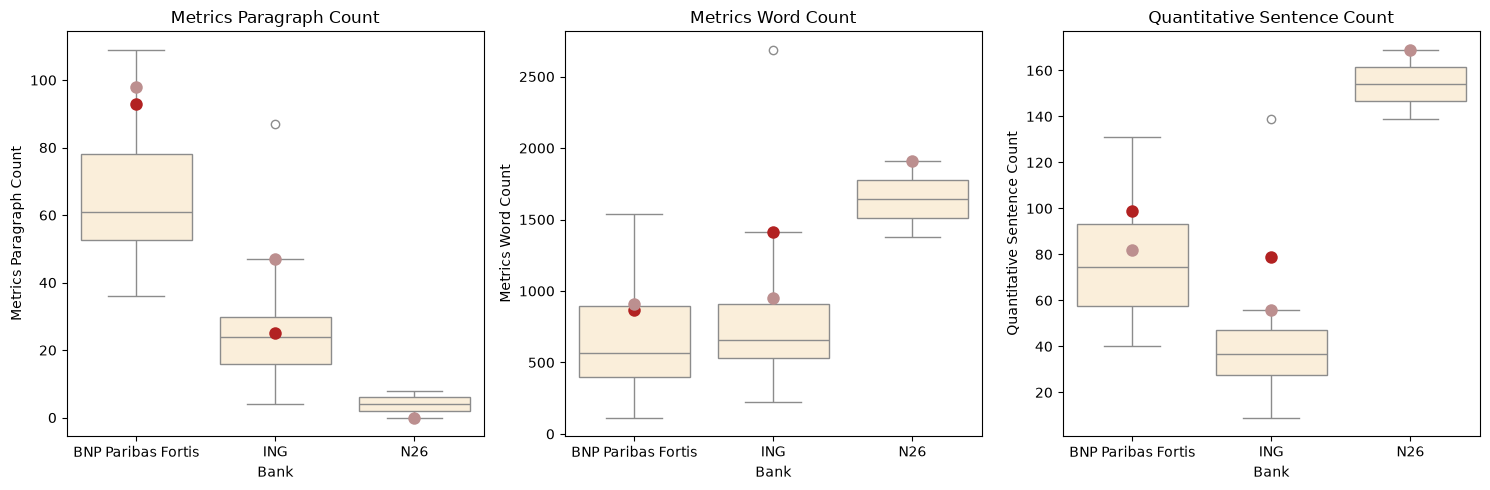

In [28]:
my_urls_2 = [
    "https://www.ing.be/en/individuals/campaign/current-account-free-youth",
    "https://www.bnpparibasfortis.be/en/public/individuals/daily-banking/accounts/current-account/youth-account"

]

my_urls_3 = [
    "https://www.bnpparibasfortis.be/en/public/individuals/daily-banking/accounts/current-account-compare",
    "https://www.ing.be/en/individuals/current-accounts-packs",
    "https://n26.com/en-be/plans"

]

# Select the two URLs you want to highlight
highlight = df['url'].isin(my_urls_2)
highlight_3 = df['url'].isin(my_urls_3)

metrics = [
    'metrics_paragraph_count',
    'metrics_word_count',
    'quantitative_sentence_count'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, metrics):
    sns.boxplot(
        data=df,
        x='bank',
        y=metric,
        ax=ax,
        color = 'papayawhip'
    )

    # Highlight the two selected URLs
    sns.stripplot(
        data=df[highlight],
        x='bank',
        y=metric,
        color='firebrick',
        size=9,
        jitter=False,
        ax=ax
    )

        # Highlight the two selected URLs
    sns.stripplot(
        data=df[highlight_3],
        x='bank',
        y=metric,
        color='rosybrown',
        size=9,
        jitter=False,
        ax=ax
    )
    
    ax.set_xlabel('Bank')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.set_title(metric.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()